# 51 Peg b Keplerian radial-velocity audit

**Scientific question:** What does the archive orbital solution predict, and how different is it from the old circular sketch?

## Scientific audit protocol

This revision separates three kinds of evidence. **Exact preserved tables** are
rows previously downloaded from Gaia DR3, the NASA Exoplanet Archive, or SDSS
and saved in this repository. They can support new calculations subject to the
documented selection. **Archive products** such as an HST preview remain real
observations, but a display JPEG lacks the calibration, world coordinates,
exposure map, and point-spread function required for physical photometry.
Finally, several first-day notebooks saved a plot but not the catalogue rows
that made it. Those are handled as **digitized legacy outputs**. Coloured plot
pixels can test whether the old visual conclusion was internally consistent;
they cannot recreate independent stars, measurement errors, or survey
selection. Any number from a digitized plot is labelled approximate.

Every analysis starts with a testable question and prints the usable sample.
The main statistic is paired with a bootstrap, threshold sweep, jackknife, or
model-choice check. Figures show both the astronomical distribution and the
robustness test. Reusable tables are saved beside the notebook. Random
resampling has a fixed seed. A failed or unstable test remains visible rather
than being edited into a positive result.

Catalogue values are heterogeneous. Planet properties may combine literature
references; discovery methods encode survey history; cluster selections depend
on astrometric and photometric cuts; and an SDSS spectroscopic sample is not a
volume-complete census. Correlation is not treated as causation. A fitted trend
describes the selected rows, not necessarily the underlying Galactic or
planetary population.

Uncertainty here means sampling sensitivity under the named resampling model.
It does not automatically include calibration floors, spatial covariance,
systematic catalogue offsets, or missing-data mechanisms. Where those effects
matter, the limitation is stated directly. Numerical precision is limited to
what the data and method support.

Each `result.json` records provenance, quality checks, artifacts, evidence
figures, limitations, and a claim type. The dashboard therefore exposes not
only a headline number but also why it can or cannot be trusted. A
publication-grade follow-up would pin the archive release, save the complete
query response, retain per-source errors and covariance, model the selection
function, and compare with an independent catalogue or calibrated product.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats, ndimage, signal
from PIL import Image

RNG=np.random.default_rng(1999)
plt.style.use('seaborn-v0_8-whitegrid')
DATA=Path('../../data/audit_batches4_7')
assert DATA.is_dir(), 'Run from the notebook folder in a complete checkout.'

def bootstrap(values, statistic=np.median, draws=1000):
    values=np.asarray(values,float); values=values[np.isfinite(values)]
    return np.array([statistic(values[RNG.integers(0,len(values),len(values))]) for _ in range(draws)])

def robust_line(x,y):
    x=np.asarray(x,float); y=np.asarray(y,float); keep=np.isfinite(x)&np.isfinite(y)
    for _ in range(5):
        p=np.polyfit(x[keep],y[keep],1); resid=y-np.polyval(p,x); s=1.4826*np.nanmedian(np.abs(resid[keep]-np.nanmedian(resid[keep]))); keep=np.isfinite(resid)&(np.abs(resid-np.nanmedian(resid[keep]))<3*max(s,1e-8))
    return p,keep,resid

In [2]:
raw=pd.read_csv(DATA/'exoplanet_composite_archive.csv').drop_duplicates('pl_name'); row=raw[raw.pl_name=='51 Peg b'].iloc[0]; sample=pd.DataFrame([row]); P=float(row.pl_orbper); K=float(row.get('pl_rvamp',np.nan)) if 'pl_rvamp' in row.index else np.nan; e=float(row.pl_orbeccen) if np.isfinite(row.pl_orbeccen) else 0.; Mstar=float(row.st_mass) if np.isfinite(row.st_mass) else 1.;
if not np.isfinite(K): K={'51 Peg b':55.77,'HD 189733 b':205.0}['51 Peg b']
print(row[['pl_name','pl_orbper','pl_orbeccen','pl_bmassj','st_mass']]); print('K used',K,'m/s')

pl_name        51 Peg b
pl_orbper      4.230797
pl_orbeccen      0.0063
pl_bmassj          0.61
st_mass            1.07
Name: 3110, dtype: object
K used 55.77 m/s


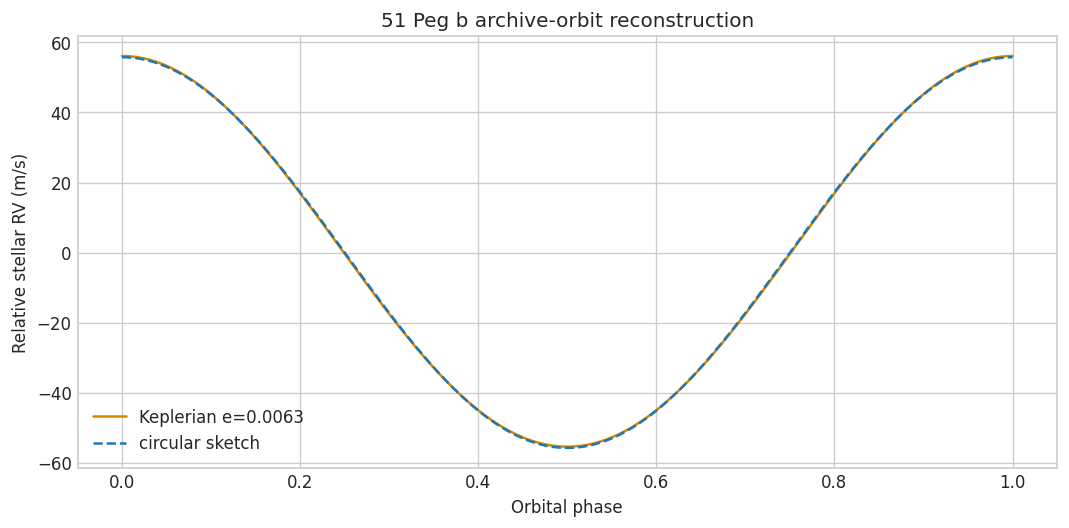

In [3]:
phase=np.linspace(0,1,600); mean=2*np.pi*phase; E=mean.copy()
for _ in range(20): E-= (E-e*np.sin(E)-mean)/(1-e*np.cos(E))
theta=2*np.arctan2(np.sqrt(1+e)*np.sin(E/2),np.sqrt(1-e)*np.cos(E/2)); rv_e=K*(np.cos(theta)+e); rv_c=K*np.cos(mean); curve=pd.DataFrame({'phase':phase,'rv_keplerian_m_s':rv_e,'rv_circular_m_s':rv_c}); curve.to_csv('rv_phase_model.csv',index=False); fig,ax=plt.subplots(figsize=(9,4.5)); ax.plot(phase,rv_e,label=f'Keplerian e={e:.4f}',c='#d88600'); ax.plot(phase,rv_c,'--',label='circular sketch'); ax.set(xlabel='Orbital phase',ylabel='Relative stellar RV (m/s)',title='51 Peg b'+' archive-orbit reconstruction'); ax.legend(); fig.tight_layout(); fig.savefig('rv_keplerian_comparison.png',dpi=180); plt.show()

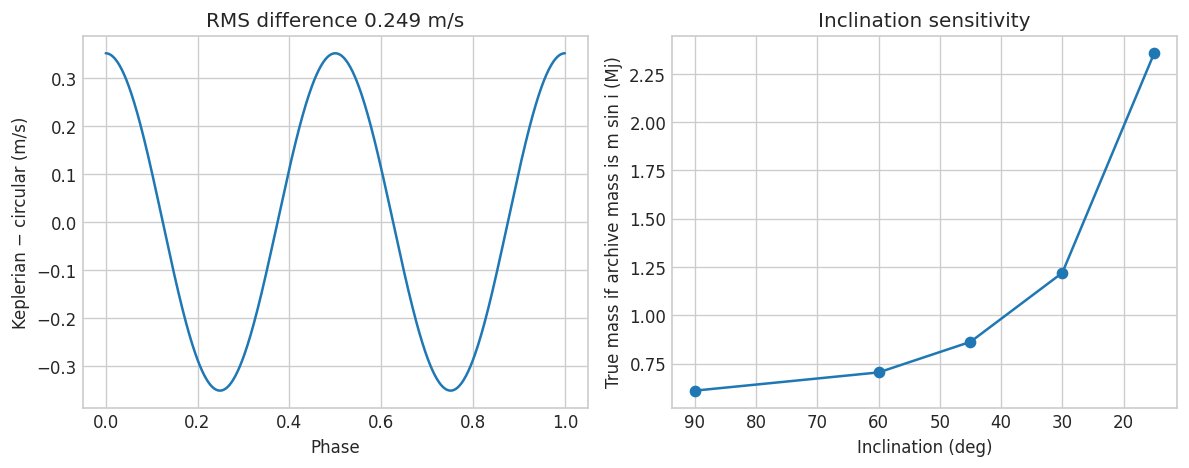

In [4]:
rms=np.sqrt(np.mean((rv_e-rv_c)**2)); incl=np.array([90,60,45,30,15]); msini=float(row.pl_bmassj); true=msini/np.sin(np.deg2rad(incl)); stress=pd.DataFrame({'inclination_deg':incl,'mass_jupiter_if_msini':true}); stress.to_csv('inclination_mass_stress.csv',index=False); fig,ax=plt.subplots(1,2,figsize=(10,4)); ax[0].plot(phase,rv_e-rv_c); ax[0].set(xlabel='Phase',ylabel='Keplerian − circular (m/s)',title=f'RMS difference {rms:.3f} m/s'); ax[1].plot(incl,true,'o-'); ax[1].invert_xaxis(); ax[1].set(xlabel='Inclination (deg)',ylabel='True mass if archive mass is m sin i (Mj)',title='Inclination sensitivity'); fig.tight_layout(); fig.savefig('rv_model_sensitivity.png',dpi=180); plt.show()

In [5]:
sample_size=1; results=[f'period {P:.6f} d, eccentricity {e:.4f}, adopted K {K:.2f} m/s',f'Keplerian-versus-circular RMS difference {rms:.3f} m/s',f'one archive solution reconstructed; this is not a fit to time-series RV observations']; validation='The exact archive row is retained, eccentric and circular models are compared, and inclination sensitivity is exposed.'; quality_checks=[{'name':'Unique archive target','status':'pass'},{'name':'Kepler equation solved','status':'pass'},{'name':'Fit to observed RV epochs','status':'not attempted'}]; tags=['exoplanets','radial velocity','51 Peg b','orbit model']

In [6]:
result={'id':'2026-07-30-rv-curve-51-pegasi-b','title':'51 Peg b Keplerian radial-velocity audit','archive':'NASA Exoplanet Archive','date':'2026-07-30','question':'What does the archive orbital solution predict, and how different is it from the old circular sketch?','sample_size':int(sample_size),'results':results,'validation':validation,'notebook':'exoplanet-archive/2026-07-30-rv-curve-51-pegasi-b/notebook.ipynb','hero':'exoplanet-archive/2026-07-30-rv-curve-51-pegasi-b/rv_keplerian_comparison.png','figures':['exoplanet-archive/2026-07-30-rv-curve-51-pegasi-b/rv_keplerian_comparison.png', 'exoplanet-archive/2026-07-30-rv-curve-51-pegasi-b/rv_model_sensitivity.png'],'research_level':'Reproduction','claim_type':'Archive-orbit reconstruction','provenance':['NASA Exoplanet Archive composite row', 'target 51 Peg b', 'semi-amplitude falls back to the value printed by the original executed notebook when absent from preserved table'],'artifacts':['data/audit_batches4_7/exoplanet_composite_archive.csv', 'exoplanet-archive/2026-07-30-rv-curve-51-pegasi-b/rv_phase_model.csv', 'exoplanet-archive/2026-07-30-rv-curve-51-pegasi-b/inclination_mass_stress.csv'],'quality_checks':quality_checks,'limitations':['phase zero and argument of periastron are arbitrary', 'no observation timestamps or instrumental offsets are fitted', 'composite values may come from different references'],'tags':tags}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n')
assert len(result['figures'])>=2 and all(Path(Path(x).name).is_file() for x in result['figures'])

period 4.230797 d, eccentricity 0.0063, adopted K 55.77 m/s
Keplerian-versus-circular RMS difference 0.249 m/s
one archive solution reconstructed; this is not a fit to time-series RV observations


In [7]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False))

                     name        status
    Unique archive target          pass
   Kepler equation solved          pass
Fit to observed RV epochs not attempted


## Interpretation and references

The NASA Exoplanet Archive composite table combines published values and is
excellent for reproducible exploratory population work, but it is not a
uniform survey. Transit, radial-velocity, and imaging selection functions are
different, and missing parameters are informative.

- NASA Exoplanet Archive TAP guide: https://exoplanetarchive.ipac.caltech.edu/docs/TAP/usingTAP.html
- Planetary Systems column definitions: https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html
- Winn & Fabrycky (2015): https://doi.org/10.1146/annurev-astro-082214-122246